In [23]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [25]:
DATA_DIR = Path(r"F:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260402_frag_cptac_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [26]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [27]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [28]:
sample_id_col = "common_ID"
purity_map = dict(zip(meta_include[sample_id_col], meta_include["FirstCategory"]))
stage_map = dict(zip(meta_include[sample_id_col], meta_include["stage"]))
gleason_map = dict(zip(meta_include[sample_id_col], meta_include["Grade_Group"]))

In [29]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [32]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [33]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"prot_TMT_ratio_gene_MD",i.stem, re.IGNORECASE) and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
print(data_path)
header_cols = ["geneSymbol","Index"]
data = pd.read_csv(data_path,sep="\t").set_index(header_cols)
data_nomiss = data.dropna()

F:\lab\cptac_prostate\data\v4\CPTAC\prostate_CPTAC_prot_TMT_ratio_gene_MD.tsv


In [34]:
files

[WindowsPath('F:/lab/cptac_prostate/data/v4/CPTAC/prostate_CPTAC_prot_TMT_ratio_gene_MD.tsv')]

In [35]:
data

,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
geneSymbol,Index,,,,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
DPM1,ENSG00000000419,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
SCYL3,ENSG00000000457,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
C1orf112,ENSG00000000460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFH,ENSG00000000971,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289694,ENSG00000289694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000289697,ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345
HOMEZ,ENSG00000290292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
data_nomiss

,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
geneSymbol,Index,,,,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
DPM1,ENSG00000000419,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
SCYL3,ENSG00000000457,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
CFH,ENSG00000000971,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
FUCA2,ENSG00000001036,0.132835,0.207359,0.135986,-0.647224,0.172049,-0.760730,-0.870467,-0.254506,0.444387,0.165997,...,0.154154,-0.151535,-0.456293,-0.256156,0.131682,-0.282375,0.639959,-0.627785,-0.318943,0.898515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288796,ENSG00000288796,-1.068650,0.417497,-1.231578,-0.530920,-0.639223,0.648059,-1.358671,0.233100,-1.348565,-0.207924,...,-0.411718,-0.681520,-0.187508,-0.753332,-1.003439,-0.204751,-0.688342,1.252445,-0.843930,-1.300777
ENSG00000289027,ENSG00000289027,0.072731,-0.120512,0.531986,0.003065,-0.086533,0.441264,0.369004,0.183412,-0.311955,0.016014,...,0.076955,-0.178163,-0.055852,0.174857,0.129082,0.455865,0.244800,-0.142812,0.239893,0.150398
ENSG00000289697,ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345


In [37]:
samples = data.columns.tolist()
len(samples)

178

In [38]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 178)


In [39]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Axes: >

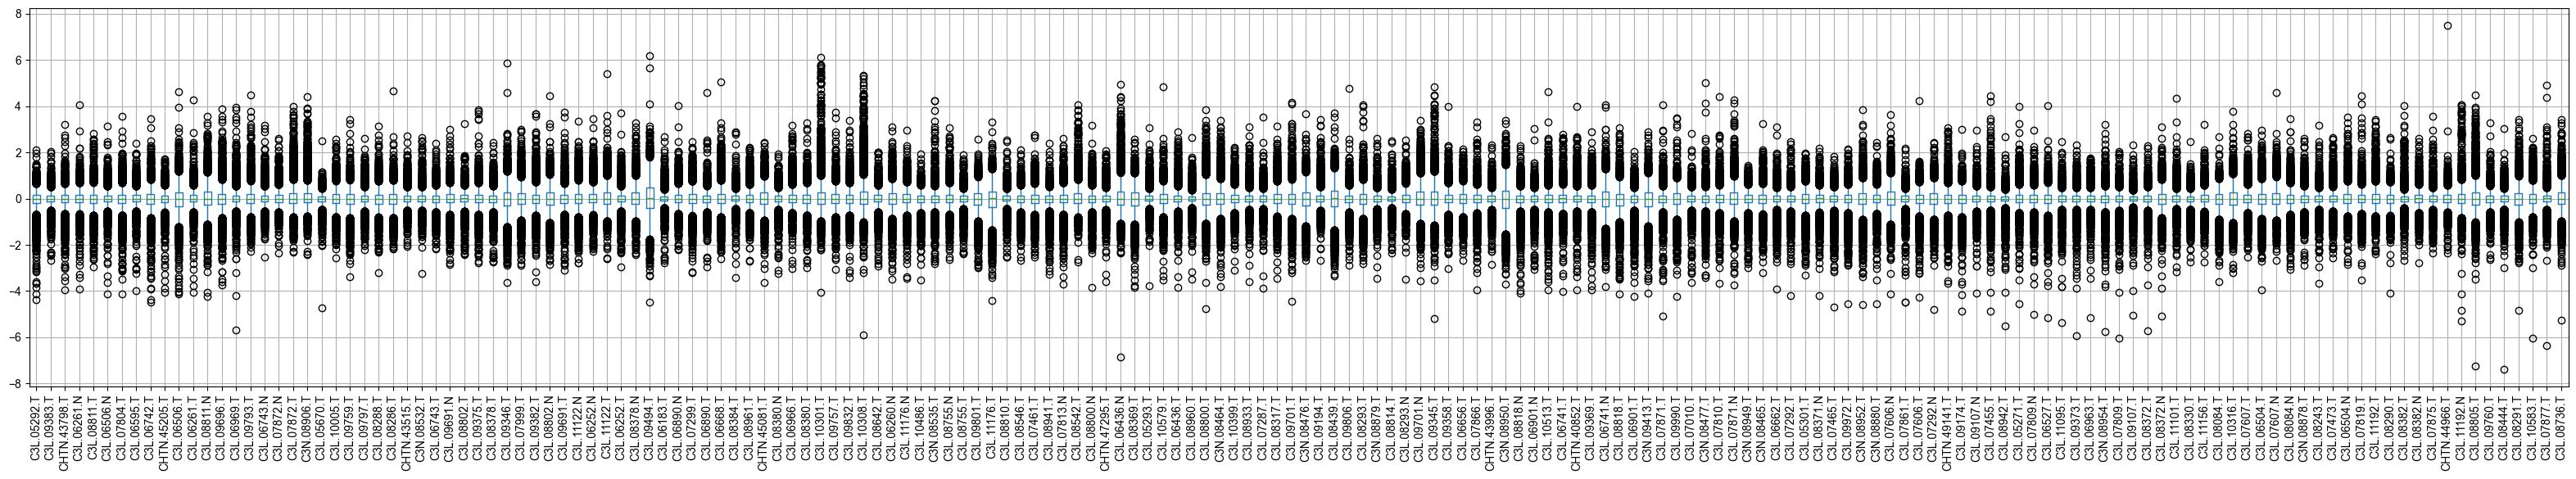

In [40]:
data.boxplot(figsize=(40,6), rot=90)

In [41]:
from omicsone_streamlit.plots.pca import plot_pca1

In [42]:
print(len(tumors_included), len(normals))

134 33


In [43]:
len(set(data.columns) & set(tumors_included))

134

In [44]:
xlim = (-60,60)
ylim = (-60,60)

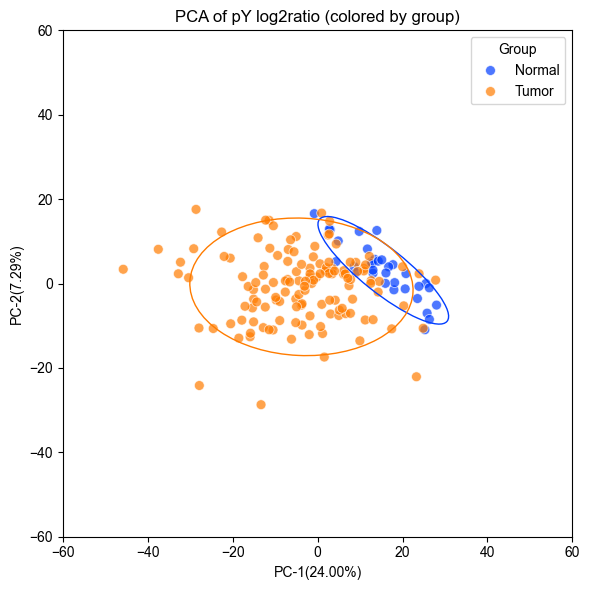

In [45]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title="PCA of pY log2ratio (colored by group)")

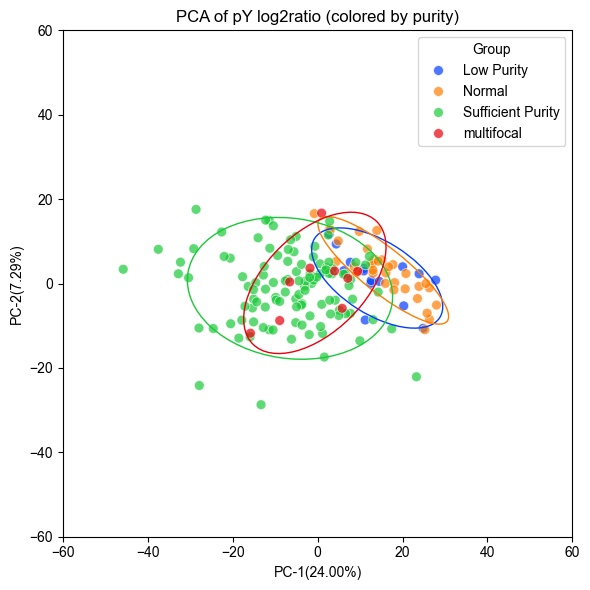

In [46]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title="PCA of pY log2ratio (colored by purity)")

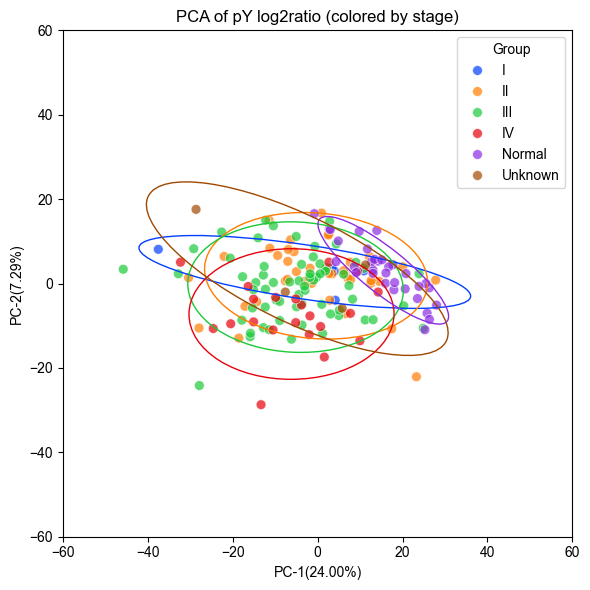

In [47]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title="PCA of pY log2ratio (colored by stage)")

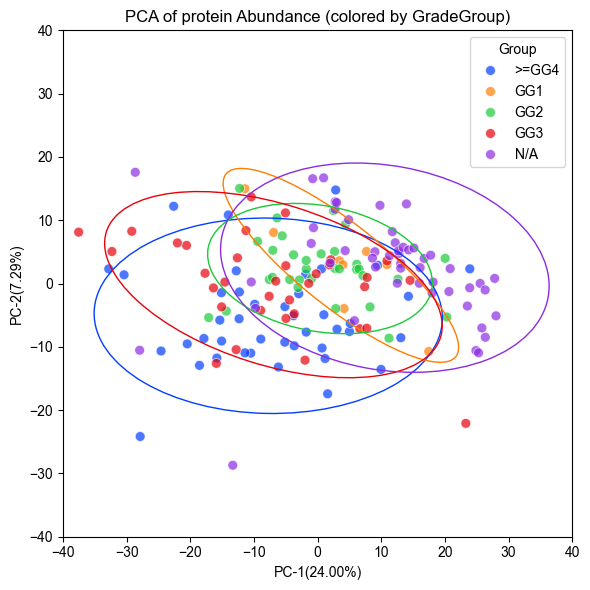

In [50]:
xlim = (-40,40)
ylim = (-40,40)
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title="PCA of protein Abundance (colored by GradeGroup)")